Load packages

In [1]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn import preprocessing
from sklearn import metrics


Load dataset

In [2]:
iris_data = load_iris()
iris_data

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [7]:
data_keys = list(iris_data.keys())
print(data_keys)

['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module']


In [ ]:
# Data information
print(iris_data["DESCR"])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [193]:
class_names = iris_data.target_names
class_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

Load data into frame

In [80]:
import pandas as pd

iris_features = pd.DataFrame(data=iris_data["data"], columns=iris_data["feature_names"])
iris_target = pd.Series(data=iris_data["target"], name="target")

iris_df = pd.concat([iris_features, iris_target], axis=1)
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Clean and Explore data

In [81]:
# normalize column
def normalize_column(column):
    new_column = column.lower().strip().split(" ")
    if len(new_column) > 1:
        new_column = "_".join(new_column[:-1])
    else:
        new_column = new_column[0]

    return new_column

iris_df.columns = iris_df.columns.map(normalize_column)
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [82]:
iris_df.shape

(150, 5)

In [83]:
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   target        150 non-null    int32  
dtypes: float64(4), int32(1)
memory usage: 5.4 KB


In [84]:
# check for missing data
iris_df.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
target          0
dtype: int64

In [85]:
# check for duplicate data
iris_df.duplicated().sum()

1

In [ ]:
# view duplicated data
iris_df.loc[iris_df.duplicated(keep=False)]

,sepal_length,sepal_width,petal_length,petal_width,target
101,5.8,2.7,5.1,1.9,2
142,5.8,2.7,5.1,1.9,2


In [ ]:
# drop duplicated data
iris_df = iris_df.drop_duplicates(keep="first")
iris_df.shape

(149, 5)

In [89]:
# get data statistics
iris_df.describe()

,sepal_length,sepal_width,petal_length,petal_width,target
count,149.000000,149.000000,149.000000,149.000000,149.000000
mean,5.843624,3.059732,3.748993,1.194631,0.993289
std,0.830851,0.436342,1.767791,0.762622,0.817847
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.300000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


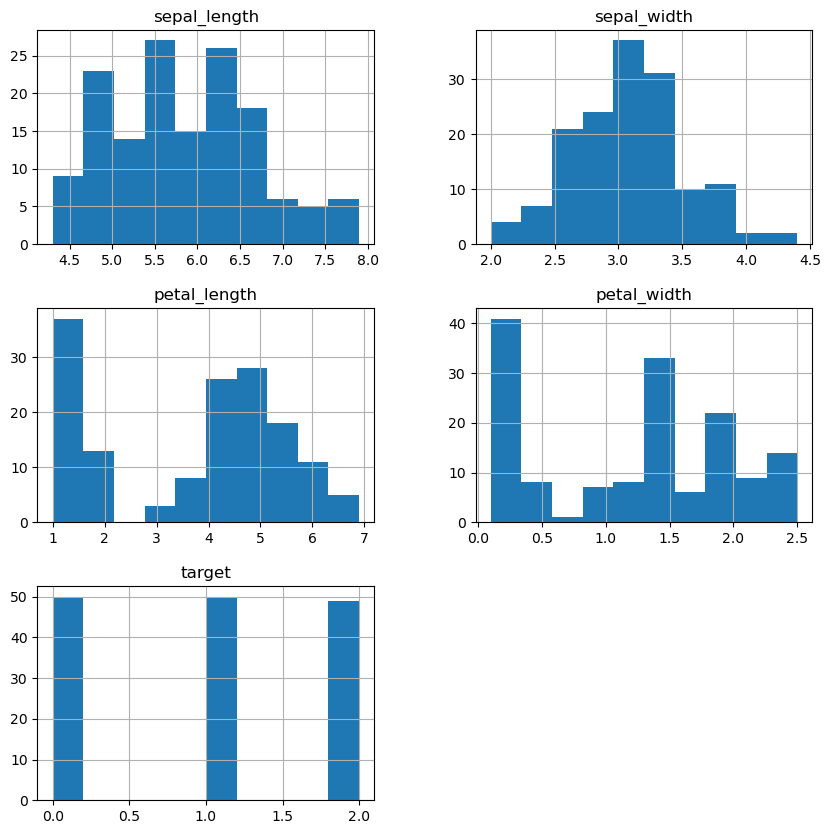

In [90]:
# check data distribution
ax = iris_df.hist(figsize=(10, 10), bins=10)

<Axes: xlabel='target'>

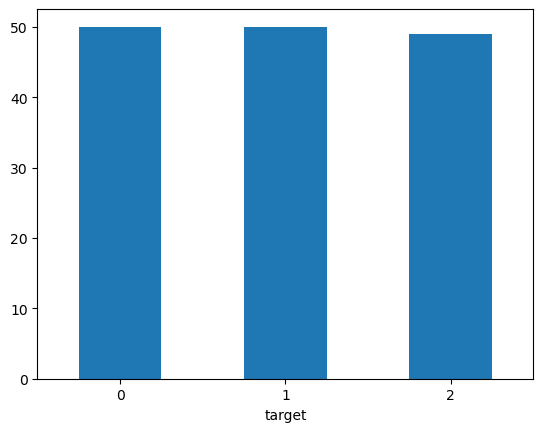

In [130]:
# target distribution count
iris_df["target"].value_counts().plot.bar(rot=0)

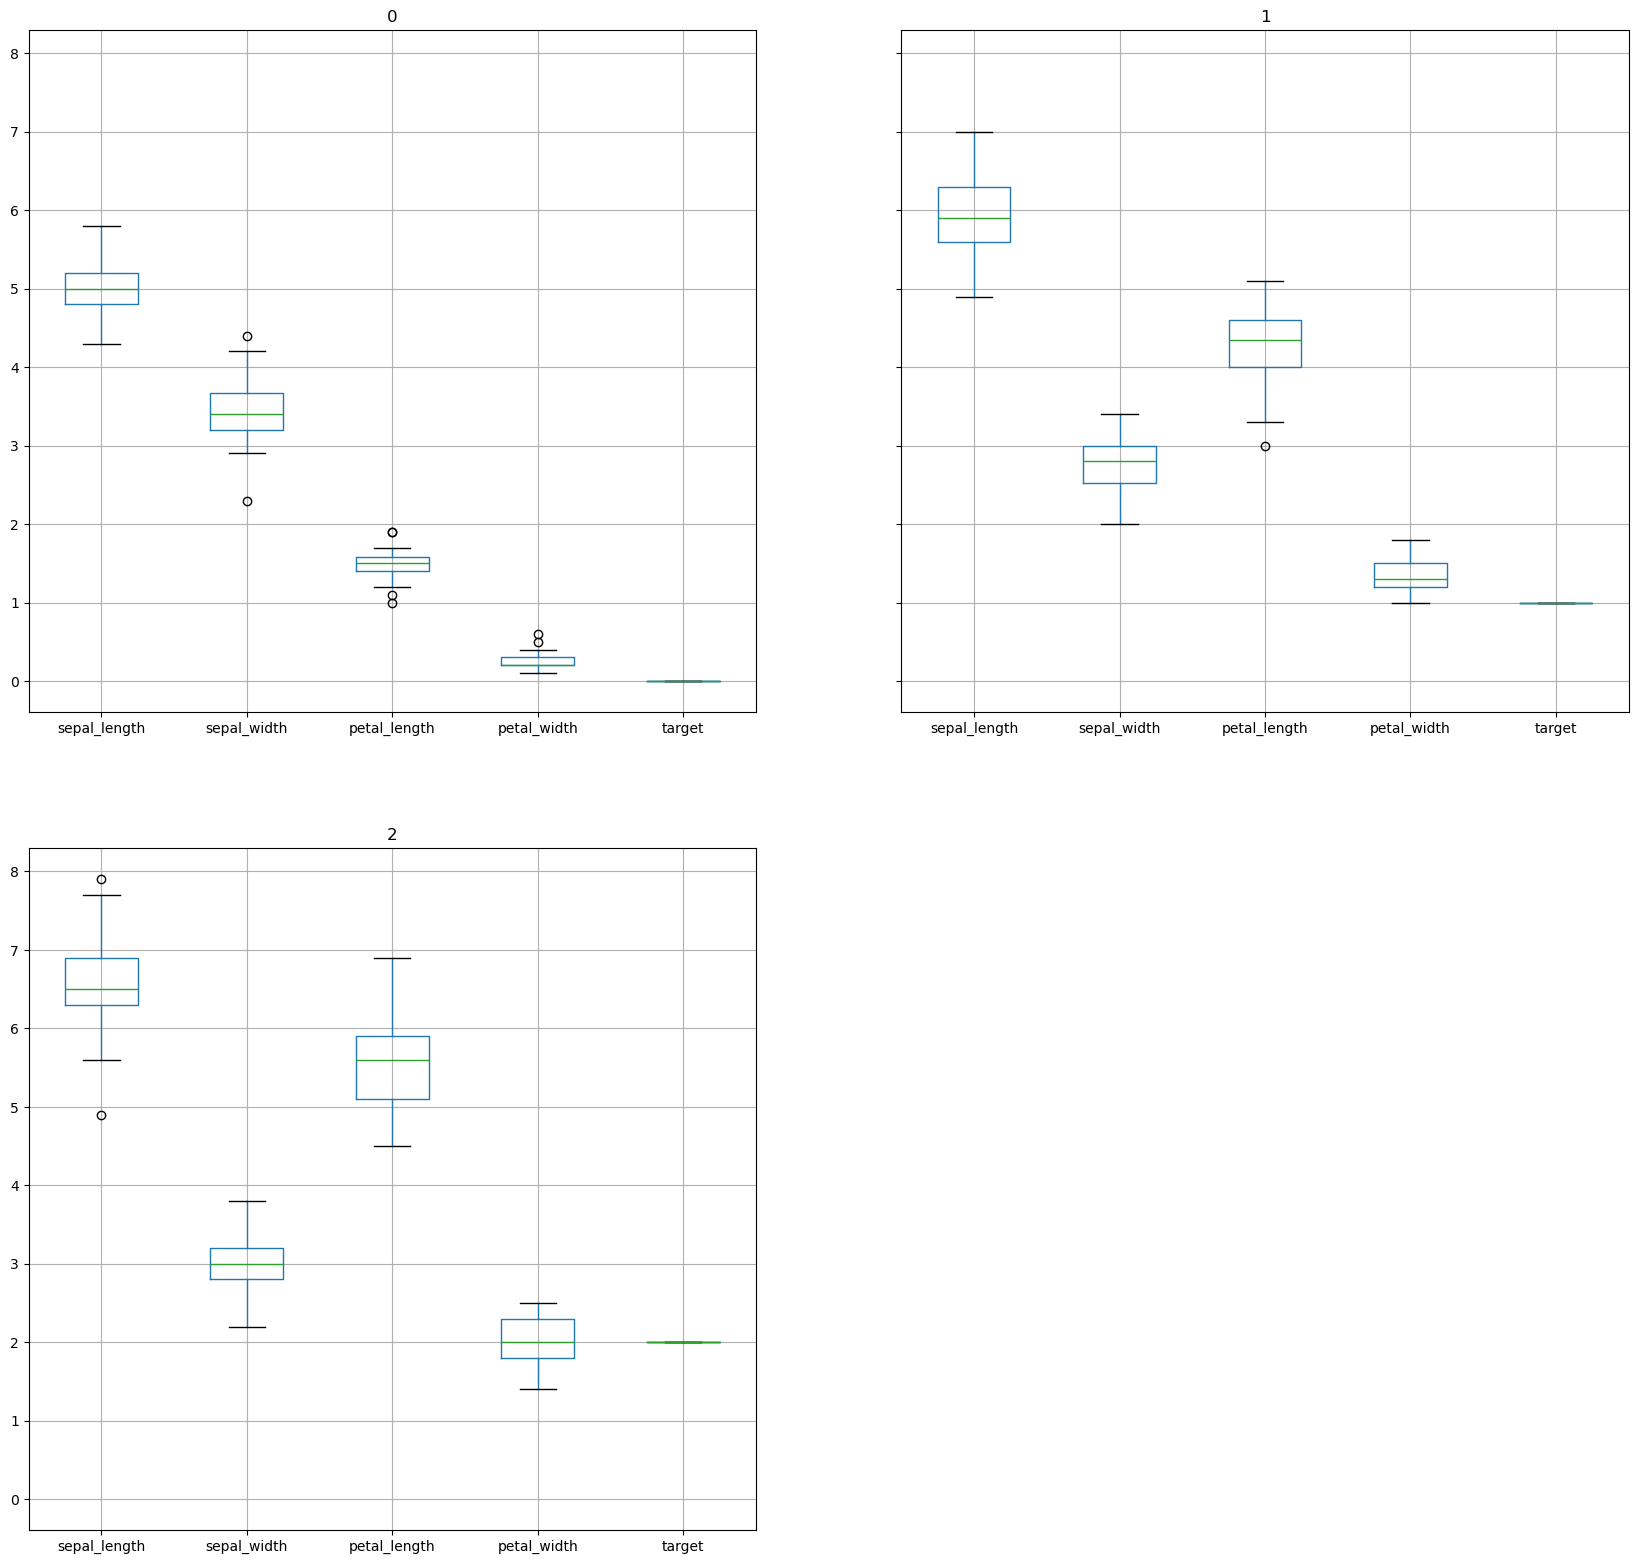

In [100]:
ax = iris_df.groupby(by="target").boxplot(figsize=(20, 20), subplots=True)

In [ ]:
# view variable statisitcs for all classes
for idx, col in enumerate(iris_df.columns):
    print(f"Displaying statisitcs for {col}")
    print(iris_df.groupby("target")[col].describe(), end="\n\n\n")

Displaying statisitcs for sepal_length
        count      mean       std  min  25%  50%  75%  max
target                                                    
0        50.0  5.006000  0.352490  4.3  4.8  5.0  5.2  5.8
1        50.0  5.936000  0.516171  4.9  5.6  5.9  6.3  7.0
2        49.0  6.604082  0.632113  4.9  6.3  6.5  6.9  7.9


Displaying statisitcs for sepal_width
        count      mean       std  min    25%  50%    75%  max
target                                                        
0        50.0  3.428000  0.379064  2.3  3.200  3.4  3.675  4.4
1        50.0  2.770000  0.313798  2.0  2.525  2.8  3.000  3.4
2        49.0  2.979592  0.323380  2.2  2.800  3.0  3.200  3.8


Displaying statisitcs for petal_length
        count      mean       std  min  25%   50%    75%  max
target                                                       
0        50.0  1.462000  0.173664  1.0  1.4  1.50  1.575  1.9
1        50.0  4.260000  0.469911  3.0  4.0  4.35  4.600  5.1
2        49.0  5.56122

In [138]:
correlations = iris_df.corr()
correlations["target"]

sepal_length    0.786971
sepal_width    -0.422987
petal_length    0.949402
petal_width     0.956514
target          1.000000
Name: target, dtype: float64

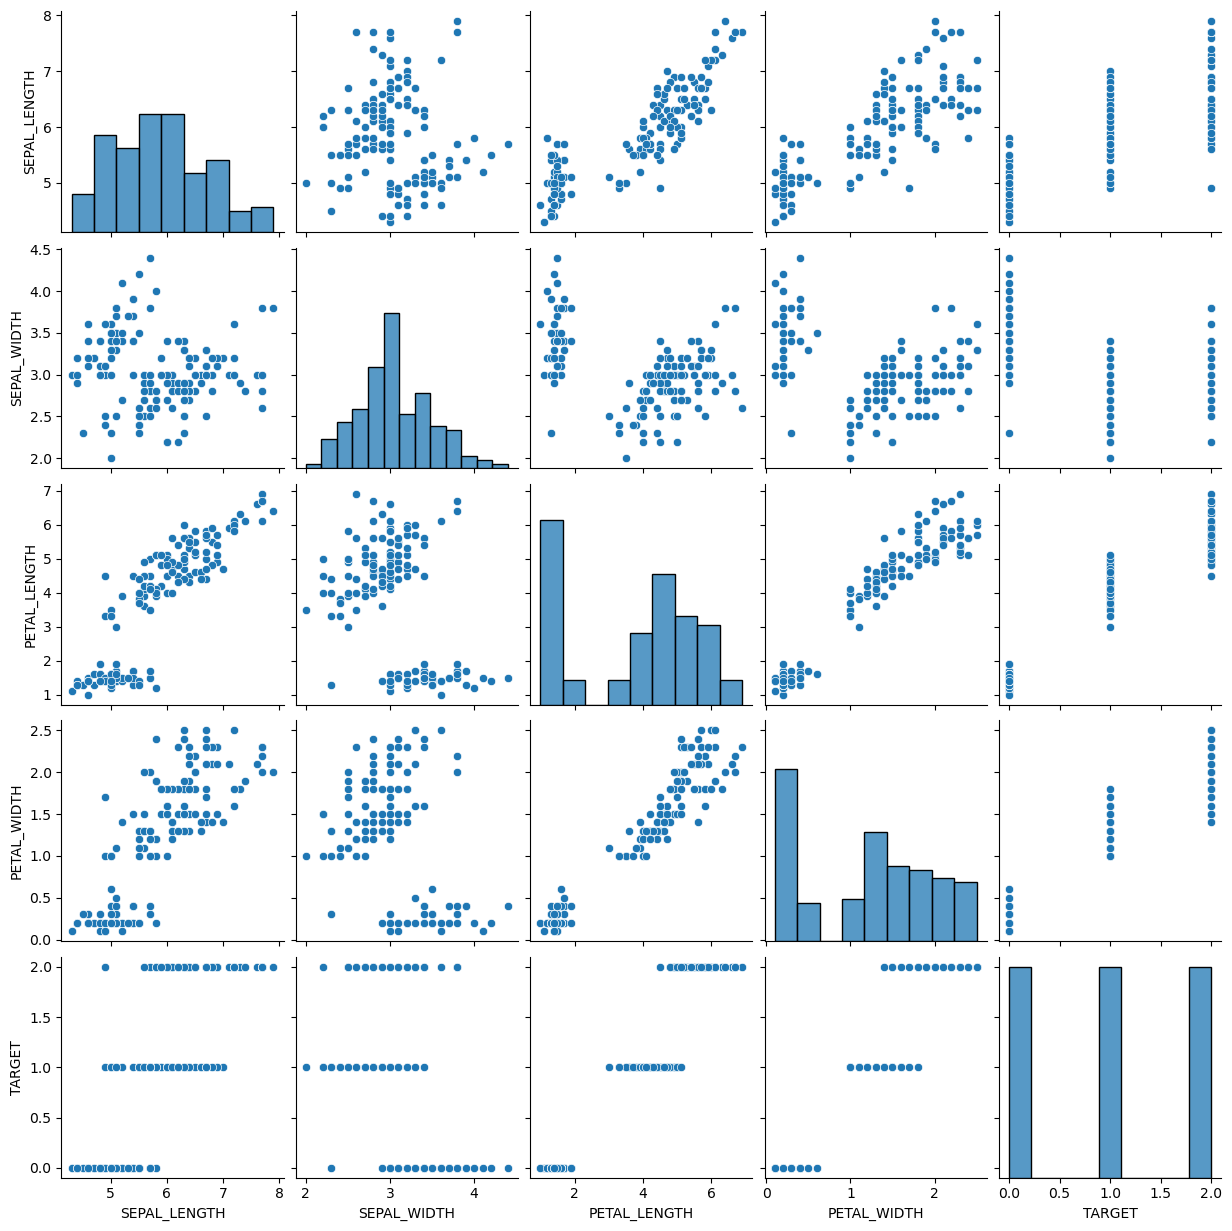

In [52]:
import seaborn as sns

sns.pairplot(iris_df)

Split data

In [163]:
train_df, test_df = train_test_split(iris_df, stratify=iris_df["target"], test_size=0.2, random_state=42)
train_df.head()

,sepal_length,sepal_width,petal_length,petal_width,target
6,4.6,3.4,1.4,0.3,0
128,6.4,2.8,5.6,2.1,2
95,5.7,3.0,4.2,1.2,1
44,5.1,3.8,1.9,0.4,0
30,4.8,3.1,1.6,0.2,0


Scale data

In [164]:
xtrain = train_df.iloc[:, :-1]
ytrain = train_df.iloc[:, -1]

xtest = test_df.iloc[:, :-1]
ytest = test_df.iloc[:, -1]

scaler = preprocessing.StandardScaler()
normalized_xtrain = scaler.fit_transform(xtrain)
normalized_xtest = scaler.transform(xtest)


Cross-validate some models

In [165]:
# linear models
from sklearn.linear_model import LogisticRegression, RidgeClassifier

lr_scores = cross_val_score(LogisticRegression(), normalized_xtrain, ytrain, cv=5)
print("Mean Logistic Regression Score:", np.round(lr_scores.mean(), decimals=2))

ridge_scores = cross_val_score(RidgeClassifier(), normalized_xtrain, ytrain, cv=5)
print("Mean Ridge Classifier Score:", np.round(lr_scores.mean(), decimals=4))

Mean Logistic Regression Score: 0.96
Mean Ridge Classifier Score: 0.9583


In [166]:
# kernel models
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

svc_scores = cross_val_score(SVC(), normalized_xtrain, ytrain, cv=5)
print("Mean SVC Score:", np.round(svc_scores.mean(), decimals=2))

knn_scores = cross_val_score(KNeighborsClassifier(), normalized_xtrain, ytrain, cv=5)
print("Mean KNN Classifier Score:", np.round(lr_scores.mean(), decimals=4))


Mean SVC Score: 0.97
Mean KNN Classifier Score: 0.9583


In [167]:
# tree model
from sklearn.tree import DecisionTreeClassifier

dt_scores = cross_val_score(DecisionTreeClassifier(), normalized_xtrain, ytrain, cv=5)
print("Mean Decision Tree score:", np.round(dt_scores.mean(), decimals=4))

Mean Decision Tree score: 0.9667


In [168]:
# Ensemble model
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier

rf_scores = cross_val_score(RandomForestClassifier(), normalized_xtrain, ytrain, cv=5)
print("Mean Random Forest score:", np.round(rf_scores.mean(), 2))

adaboost = AdaBoostClassifier()
adb_scores = cross_val_score(adaboost, normalized_xtrain, ytrain, cv=5)
print("Mean AdaBoost Classifier score:", np.round(adb_scores.mean(), 4))

Mean Random Forest score: 0.95
Mean AdaBoost Classifier score: 0.95


In [169]:
# neaural network models
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import SGDClassifier

sgd_score = cross_val_score(SGDClassifier(), normalized_xtrain, ytrain, cv=5)
print("Mean SGD score:", np.round(sgd_score.mean(), 2))

mlp_score = cross_val_score(MLPClassifier(), normalized_xtrain, ytrain, cv=5)
print("Mean mlp score:", np.round(mlp_score.mean(), 4))


Mean SGD score: 0.96
Mean mlp score: 0.9583


Train Support Vector Classifier

In [170]:
classifier = SVC()
classifier.fit(normalized_xtrain, ytrain)
classifier.score(normalized_xtest, ytest)

0.9666666666666667

Create pipeline

In [174]:
from sklearn.pipeline import make_pipeline, Pipeline

pipeline = Pipeline(steps=[
    ("scaler", preprocessing.StandardScaler()),
    ("classifier", SVC())
    ])

pipeline.fit(xtrain, ytrain)
pipeline.score(xtest, ytest)

0.9666666666666667

Evaluate pipeline

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

In [194]:
# get prediction
test_pred = pipeline.predict(xtest)

In [195]:
# classification report
report = classification_report(ytest, test_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



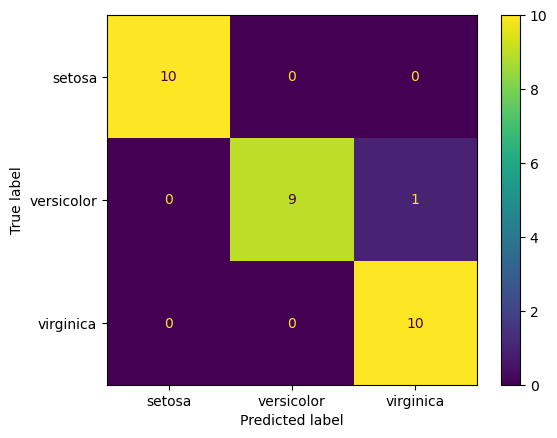

In [196]:
# confusion matrix
cm = confusion_matrix(ytest, test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot()

Save pipeline model

In [197]:
import os
import joblib
model_dir = os.path.join("app", "model")

os.makedirs(model_dir, exist_ok=True)
joblib.dump(pipeline, filename=os.path.join(model_dir, "model.joblib"))

['app\\model\\model.joblib']

In [ ]:
# predictive features
xtrain.columns.tolist()

['sepal_length', 'sepal_width', 'petal_length', 'petal_width']